In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# This copies your data from the slow Drive to the fast local /content/ folder
import shutil

print("🚚 Copying data to local storage (this takes a few minutes but saves hours later)...")
shutil.copytree("/content/drive/MyDrive/data", "/content/local_data", dirs_exist_ok=True)
print("✅ Done! Data is now on the local SSD.")

🚚 Copying data to local storage (this takes a few minutes but saves hours later)...
✅ Done! Data is now on the local SSD.


In [ ]:
import os
from pathlib import Path
import math
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
data_dir = "/content/drive/MyDrive/data"   # change only if needed
local_data_dir = "/content/local_data"
print(os.listdir(data_dir))

['.DS_Store', 'train', 'validate', 'test']


Checking dataset

In [ ]:
from pathlib import Path

train_comp = Path(f"{data_dir}/train/compressed")
train_gt = Path(f"{data_dir}/train/ground_truth")

comp_files = sorted([p for p in train_comp.iterdir() if p.is_file()])
gt_files = sorted([p for p in train_gt.iterdir() if p.is_file()])

print("compressed count:", len(comp_files))
print("ground truth count:", len(gt_files))

print("sample compressed:", [p.name for p in comp_files[:10]])
print("sample ground truth:", [p.name for p in gt_files[:10]])

compressed count: 8000
ground truth count: 8000
sample compressed: ['1.jp2', '10.jp2', '100.jp2', '1000.jp2', '1001.jp2', '1002.jp2', '1003.jp2', '1004.jp2', '1005.jp2', '1006.jp2']
sample ground truth: ['1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png', '1006.png']


In [ ]:
comp_stems = {p.stem for p in comp_files}
gt_stems = {p.stem for p in gt_files}

only_in_comp = sorted(comp_stems - gt_stems)
only_in_gt = sorted(gt_stems - comp_stems)

print("Only in compressed:", len(only_in_comp))
print("Only in ground_truth:", len(only_in_gt))

print("Examples only in compressed:", only_in_comp[:20])
print("Examples only in ground_truth:", only_in_gt[:20])

Only in compressed: 0
Only in ground_truth: 0
Examples only in compressed: []
Examples only in ground_truth: []


DATASET CLASS

In [ ]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF  # Added the functional transforms

class PairedImageDataset(Dataset):
    def __init__(self, compressed_dir, ground_truth_dir, image_size=None, mode="RGB"):
        self.compressed_dir = Path(compressed_dir)
        self.ground_truth_dir = Path(ground_truth_dir)
        self.mode = mode
        self.image_size = image_size  # Saved as a class variable for later

        # 1. Gather all files
        comp_files = [p for p in self.compressed_dir.iterdir() if p.is_file()]
        gt_files = [p for p in self.ground_truth_dir.iterdir() if p.is_file()]

        # 2. Build the dictionaries mapping stems to full paths
        comp_map = {p.stem: p for p in comp_files}
        gt_map = {p.stem: p for p in gt_files}

        # 3. Find the exact matching overlapping pairs
        common_keys = sorted(set(comp_map.keys()) & set(gt_map.keys()))
        only_in_comp = sorted(set(comp_map.keys()) - set(gt_map.keys()))
        only_in_gt = sorted(set(gt_map.keys()) - set(comp_map.keys()))

        # 4. Print the debug/sanity check stats
        print(f"Matched pairs: {len(common_keys)}")
        print(f"Skipped (only in compressed): {len(only_in_comp)}")
        print(f"Skipped (only in ground_truth): {len(only_in_gt)}")

        if len(only_in_comp) > 0:
            print("Examples only in compressed:", only_in_comp[:10])
        if len(only_in_gt) > 0:
            print("Examples only in ground_truth:", only_in_gt[:10])

        # 5. Lock in the matched pairs
        self.pairs = [(comp_map[k], gt_map[k]) for k in common_keys]

        # 6. We only keep ToTensor here; cropping happens dynamically in __getitem__
        self.transform = T.Compose([T.ToTensor()])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        comp_path, gt_path = self.pairs[idx]
        comp_img = Image.open(comp_path).convert(self.mode)
        gt_img = Image.open(gt_path).convert(self.mode)

        if self.image_size is not None:
            w, h = comp_img.size
            # If the image is too small, pad it to at least image_size
            pad_h = max(0, self.image_size - h)
            pad_w = max(0, self.image_size - w)

            if pad_h > 0 or pad_w > 0:
                # Add padding to the right and bottom using "reflect" to keep textures natural
                padding = (0, 0, pad_w, pad_h)
                comp_img = TF.pad(comp_img, padding, padding_mode='reflect')
                gt_img = TF.pad(gt_img, padding, padding_mode='reflect')

            # Now safe to get crop parameters
            i, j, h_crop, w_crop = T.RandomCrop.get_params(
                comp_img, output_size=(self.image_size, self.image_size)
            )
            comp_img = TF.crop(comp_img, i, j, h_crop, w_crop)
            gt_img = TF.crop(gt_img, i, j, h_crop, w_crop)

        return self.transform(comp_img), self.transform(gt_img), comp_path.name, gt_path.name

LOADING TRAIN/ VALIDATE / TEST SET WITH THIS CLASS

In [ ]:
IMAGE_SIZE = 256
MODE = "RGB"   # use "L" if grayscale

train_dataset = PairedImageDataset(
    compressed_dir=f"{local_data_dir}/train/compressed",
    ground_truth_dir=f"{local_data_dir}/train/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

val_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/validate/compressed",
    ground_truth_dir=f"{data_dir}/validate/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

test_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/test/compressed",
    ground_truth_dir=f"{data_dir}/test/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Matched pairs: 8000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Train size: 8000
Val size: 1000
Test size: 1000


DATALOADERS

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

batch = next(iter(train_loader))
compressed_batch, gt_batch, comp_names, gt_names = batch

print(compressed_batch.shape)
print(gt_batch.shape)
print(comp_names[:3])
print(gt_names[:3])

torch.Size([64, 3, 256, 256])
torch.Size([64, 3, 256, 256])
('490.jp2', '7508.jp2', '4041.jp2')
('490.png', '7508.png', '4041.png')


DEFINE ARCNN

In [ ]:
import torch
import torch.nn as nn

class ARCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=9, padding=4),
            nn.PReLU(),

            nn.Conv2d(64, 32, kernel_size=7, padding=3),
            nn.PReLU(),

            nn.Conv2d(32, 16, kernel_size=1, padding=0),
            nn.PReLU(),

            nn.Conv2d(16, in_channels, kernel_size=5, padding=2)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_channels = 3 if MODE == "RGB" else 1

model = ARCNN(in_channels=in_channels).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Training and validation functions

In [ ]:
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    # This bar will update for every batch (64 images at a time)
    pbar = tqdm(loader, desc="  Training", leave=False)

    for compressed, ground_truth, _, _ in pbar:
        compressed, ground_truth = compressed.to(device), ground_truth.to(device)

        optimizer.zero_grad()
        output = model(compressed)
        loss = criterion(output, ground_truth)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * compressed.size(0)

        # Update the progress bar with the current loss
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    pbar = tqdm(loader, desc="  Validating", leave=False)

    for compressed, ground_truth, _, _ in pbar:
        compressed, ground_truth = compressed.to(device), ground_truth.to(device)
        output = model(compressed)
        loss = criterion(output, ground_truth)
        running_loss += loss.item() * compressed.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)

In [ ]:
# Make sure these are set in your earlier cells
IMAGE_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 50

import torch.optim as optim

# 1. Initialize a fresh model and move to GPU
model = ARCNN(in_channels=3).to(device)

# 2. Setup Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Tracking variables
best_val_loss = float('inf')
history = {'train': [], 'val': []}

print(f"🚀 Starting Full Training: 50 Epochs on {device}...")

# 4. The Loop
for epoch in range(EPOCHS):
    # Train and Validate
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    # Store history for later plotting
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Save only the BEST version
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_arcnn_weights.pth")
        print("  🌟 Checkpoint: New best model saved!")

print("🎉 Training Complete!")

🚀 Starting Full Training: 50 Epochs on cuda...


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [001/50] | Train Loss: 0.025978 | Val Loss: 0.009511
  🌟 Checkpoint: New best model saved!


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [049/50] | Train Loss: 0.004071 | Val Loss: 0.003905
  🌟 Checkpoint: New best model saved!


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [050/50] | Train Loss: 0.004077 | Val Loss: 0.003955
🎉 Training Complete!


1.jp2 | 1.png


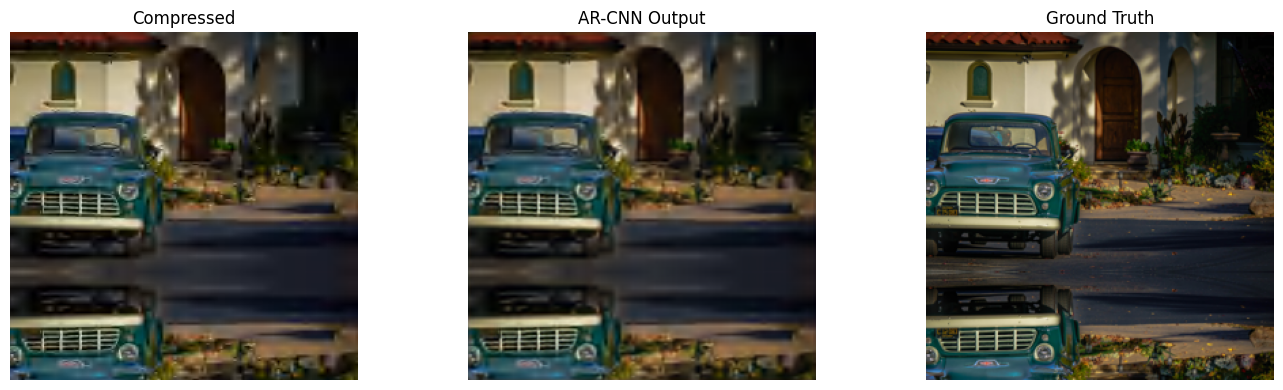

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def show_model_result(model, dataset, idx):
    model.eval()

    compressed, ground_truth, comp_name, gt_name = dataset[idx]
    inp = compressed.unsqueeze(0).to(device)
    output = model(inp).squeeze(0).cpu().clamp(0, 1)

    comp_np = compressed.permute(1, 2, 0).numpy()
    out_np = output.permute(1, 2, 0).numpy()
    gt_np = ground_truth.permute(1, 2, 0).numpy()

    if comp_np.shape[2] == 1:
        comp_np = comp_np.squeeze(-1)
        out_np = out_np.squeeze(-1)
        gt_np = gt_np.squeeze(-1)
        cmap = "gray"
    else:
        cmap = None

    print(comp_name, "|", gt_name)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(np.clip(comp_np, 0, 1), cmap=cmap)
    ax[0].set_title("Compressed")
    ax[1].imshow(np.clip(out_np, 0, 1), cmap=cmap)
    ax[1].set_title("AR-CNN Output")
    ax[2].imshow(np.clip(gt_np, 0, 1), cmap=cmap)
    ax[2].set_title("Ground Truth")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

# This calls the function for image index 0
show_model_result(model, test_dataset, idx=0)

In [16]:
# Unified evaluation: MSE + PSNR + SSIM + LPIPS in one pass

# 1) Load best weights
model.load_state_dict(torch.load("best_arcnn_weights.pth"))
model.eval()

# 2) LPIPS model
lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()

# 3) Running totals
test_mse = 0.0

total_psnr_out = 0.0
total_psnr_comp = 0.0

total_ssim_out = 0.0
total_ssim_comp = 0.0

total_lpips_out = 0.0
total_lpips_comp = 0.0

print("Evaluating on Test Set (PSNR + SSIM + LPIPS)...")
with torch.no_grad():
    for compressed, gt, _, _ in test_loader:
        compressed, gt = compressed.to(device), gt.to(device)

        output = model(compressed)
        output = torch.clamp(output, 0, 1)

        # MSE
        test_mse += torch.mean((output - gt) ** 2).item()

        # PSNR
        total_psnr_out += calculate_psnr(output, gt).item()
        total_psnr_comp += calculate_psnr(compressed, gt).item()

        # SSIM
        total_ssim_out += calculate_ssim(output, gt).item()
        total_ssim_comp += calculate_ssim(compressed, gt).item()

        # LPIPS
        total_lpips_out += calculate_lpips(lpips_model, output, gt).item()
        total_lpips_comp += calculate_lpips(lpips_model, compressed, gt).item()

n = len(test_loader)
avg_mse = test_mse / n

avg_psnr_out = total_psnr_out / n
avg_psnr_comp = total_psnr_comp / n

avg_ssim_out = total_ssim_out / n
avg_ssim_comp = total_ssim_comp / n

avg_lpips_out = total_lpips_out / n
avg_lpips_comp = total_lpips_comp / n

print("\n--- Final Results ---")
print(f"Average Test MSE: {avg_mse:.6f}")
print(f"Original Compressed PSNR: {avg_psnr_comp:.2f} dB")
print(f"AR-CNN Restored PSNR:    {avg_psnr_out:.2f} dB")
print(f"Net PSNR Improvement:    {avg_psnr_out - avg_psnr_comp:.2f} dB")

print(f"Original Compressed SSIM: {avg_ssim_comp:.4f}")
print(f"AR-CNN Restored SSIM:     {avg_ssim_out:.4f}")
print(f"Net SSIM Improvement:     {avg_ssim_out - avg_ssim_comp:.4f}")

print(f"Original Compressed LPIPS: {avg_lpips_comp:.4f}")
print(f"AR-CNN Restored LPIPS:     {avg_lpips_out:.4f}")
print(f"Net LPIPS Improvement:     {avg_lpips_comp - avg_lpips_out:.4f} (lower is better)")

FileNotFoundError: [Errno 2] No such file or directory: 'best_arcnn_weights.pth'

In [ ]:
import torch
import torch.nn.functional as F
import lpips


def calculate_psnr(img1, img2):
    """Calculates PSNR between two tensors in [0,1] with shape [B,C,H,W]."""
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return torch.tensor(100.0, device=img1.device)
    pixel_max = 1.0
    return 20 * torch.log10(torch.tensor(pixel_max, device=img1.device) / torch.sqrt(mse))


def calculate_ssim(img1, img2, window_size=11, eps=1e-8):
    """Calculates SSIM between two tensors in [0,1] with shape [B,C,H,W]."""
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    pad = window_size // 2

    mu1 = F.avg_pool2d(img1, window_size, stride=1, padding=pad)
    mu2 = F.avg_pool2d(img2, window_size, stride=1, padding=pad)

    sigma1 = F.avg_pool2d(img1 * img1, window_size, stride=1, padding=pad) - mu1 * mu1
    sigma2 = F.avg_pool2d(img2 * img2, window_size, stride=1, padding=pad) - mu2 * mu2
    sigma12 = F.avg_pool2d(img1 * img2, window_size, stride=1, padding=pad) - mu1 * mu2

    num = (2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)
    den = (mu1 * mu1 + mu2 * mu2 + c1) * (sigma1 + sigma2 + c2)

    ssim_map = num / (den + eps)
    return ssim_map.mean()


def calculate_lpips(lpips_model, img1, img2):
    """Calculates LPIPS between two tensors in [0,1] with shape [B,C,H,W]."""
    # LPIPS expects RGB and normalized range [-1, 1]
    if img1.shape[1] == 1:
        img1 = img1.repeat(1, 3, 1, 1)
        img2 = img2.repeat(1, 3, 1, 1)

    return lpips_model(img1 * 2 - 1, img2 * 2 - 1).mean()

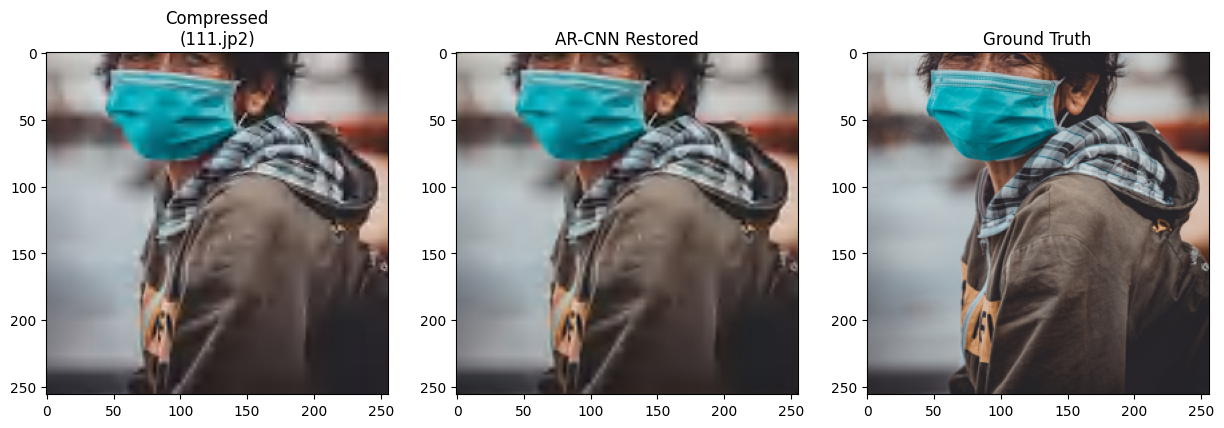

In [ ]:
def show_comparison(model, dataset, idx=0):
    model.eval()
    comp_img, gt_img, comp_name, _ = dataset[idx]

    # Prepare for model
    input_tensor = comp_img.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor).squeeze(0).cpu()
        output = torch.clamp(output, 0, 1)

    # Convert tensors to numpy for plotting
    comp_np = comp_img.permute(1, 2, 0).numpy()
    gt_np = gt_img.permute(1, 2, 0).numpy()
    out_np = output.permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(comp_np); plt.title(f"Compressed\n({comp_name})")
    plt.subplot(1, 3, 2); plt.imshow(out_np); plt.title("AR-CNN Restored")
    plt.subplot(1, 3, 3); plt.imshow(gt_np); plt.title("Ground Truth")
    plt.show()

# Run it on a specific image index
show_comparison(model, test_dataset, idx=15)